# Insect Hopper IL Pipeline

Table of contents
* [Imports](#imports)
* [Hopper Model Simluation](#hopper-model-simluation)
    * [Setup and Free Fall Simulation](#free-fall-simulation-no-actuation)
    * [Basic Hopping Simulation](#basic-hopping-simulation)
    * [Energy-Based Hopping Simulation](#energy-based-hopper-controller)
* [Data Extraction and Cleanup](#data-extraction-and-cleanup)
    * [PyTorch Dataset](#pytorch-dataset)
    * [Split into Train/Val/Test](#split-into-trainvaltest)
* [MLP Setup](#multi-layer-perceptron)
* [Training Loop](#training-loop)
* [Rollout](#rollout)
* [CEM-MPC](#cem-mpc)
    * [MuJoCo Simulation and Render](#mujoco-simulation-and-render)
    * [Evaluation Utils](#evaluation-utilities)

## Imports

In [22]:
import scipy.io
import torch.nn as nn
import torch.optim as optim
import os
import mujoco
import mujoco.viewer
import dm_control
import mediapy as media

## Hopper Model Simulation
MuJoCo hopper simulation and renders for sanity-checking

### Free Fall Simulation (No Actuation)

In [2]:
model = mujoco.MjModel.from_xml_path("flying_hopper.xml")
# model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

# enable joint visualization option:
scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True

def render(model, data, controller=lambda model, data: data, duration=3.8, framerate=60):
  """
    ### Parameters
    model: MuJoCo model\n
    data: associated data\n
    controller: function for data step, default is just data -> data\n
    duration: time of render in seconds. default = 3.8s\n
    framerate: default 60Hz
  """
  # mujoco.MjData.energy(0, 1)

  # duration = 3.8  # (seconds)
  # framerate = 60  # (Hz)

  # Simulate and display video.
  frames = []
  mujoco.mj_resetData(model, data)
  with mujoco.Renderer(model) as renderer:
    while data.time < duration:
      controller(model, data)
      mujoco.mj_step(model, data)
      if len(frames) < data.time * framerate:
        renderer.update_scene(data, scene_option=scene_option)
        pixels = renderer.render()
        frames.append(pixels)

  media.show_video(frames, fps=framerate)

render(model, data)
# viewer = mujoco.viewer
# viewer.launch(model, data)


This browser does not support the video tag.


### Basic Hopping Simulation
No MPC - Hopping by manually controlling the leg thrust

In [3]:
import numpy as np
import mujoco
import mujoco.viewer

# Physical params
m = 0.95e-3 + 0.03e-3    # robot mass (kg)
g = 9.81
h_des = 0.05             # target hop height (m)
Fmax = (m * g) * 1.5     # total max thrust from wings
leg_impulse_force = 0.03 # N (tunable, short pulse)

def hopper_controller(model, data):
    # --- Compute system energy (potential + kinetic) ---
    z = data.qpos[2]  # z-position of torso
    vz = data.qvel[2] # z-velocity
    E = m * g * z + 0.5 * m * (vz ** 2)

    # --- Energy threshold for target hop height ---
    E_target = m * g * h_des

    # --- Control logic ---
    if E < E_target and data.qpos[2] <= 0.051:  
        # Apply brief impulse with leg motor (only near ground)
        data.ctrl[0] = 1.0   # leg_motor fully activated
    else:
        data.ctrl[0] = 0.0   # no leg thrust

    # Wing thrusts: small stabilization (here just equal distribution)
    # Later, replace with attitude control (PID on roll/pitch)
    wing_thrust = 0.25 * Fmax
    data.ctrl[1:5] = [wing_thrust, wing_thrust, wing_thrust, wing_thrust]



In [4]:
render(model, data, controller=hopper_controller, duration=5.0)

# viewer = mujoco.viewer
# viewer.launch(model, data)

ValueError: could not broadcast input array from shape (4,) into shape (3,)

### Energy-Based Hopper Controller

In [ ]:
import numpy as np
import mujoco
import mujoco.viewer

# Physical params
m = 0.95e-3 + 0.03e-3    # robot mass (kg)
g = 9.81
h_des = 0.05             # target hop height (m)
Fmax = (m * g) * 1.5     # total max thrust from wings
leg_impulse_force = 0.03 # N (tunable, short pulse)

def energy_based_hopper_controller(model, data):
    # --- Compute system energy (potential + kinetic) ---
    z = data.qpos[2]  # z-position of torso
    vz = data.qvel[2] # z-velocity
    E = m * g * z + 0.5 * m * (vz ** 2)

    # --- Energy threshold for target hop height ---
    E_target = m * g * h_des

    # --- Control logic ---
    if E < E_target and data.qpos[2] <= 0.051:  
        # Apply brief impulse with leg motor (only near ground)
        data.ctrl[0] = 1.0   # leg_motor fully activated
    else:
        data.ctrl[0] = 0.0   # no leg thrust

    # Wing thrusts: small stabilization (here just equal distribution)
    # Later, replace with attitude control (PID on roll/pitch)
    wing_thrust = 0.25 * Fmax
    data.ctrl[1:5] = [wing_thrust, wing_thrust, wing_thrust, wing_thrust]


In [ ]:
render(model, data, controller=energy_based_hopper_controller, duration=5.0)

ValueError: could not broadcast input array from shape (4,) into shape (3,)

## Data Extraction and Cleanup

In [35]:
from scipy.signal import decimate
from hopper.data_utils import JumpingData
            

In [36]:

jumping_data_dir = "/Users/cassandrahe/MIT Dropbox/Cassandra He/jumping_data"
data = {}


for folder in os.listdir(jumping_data_dir):
    if folder[0] == ".": continue # to get around whatever .DS_store files dropbox adds
    print(folder)
    for file in os.listdir(f"{jumping_data_dir}/{folder}"):
        if not file.endswith(".mat"):
            continue
        print(file)
        # TODO: data processing here
        mat = scipy.io.loadmat(f"{jumping_data_dir}/{folder}/{file}")
        newdata = JumpingData(filename=file)
        newdata.load_from_dict(mat)
        data[file] = newdata



7cm_setpoint
closedloop23_Nemo44_2024-03-29_19-37-34.mat
closedloop21_Nemo44_2024-03-29_19-20-55.mat
closedloop20_Nemo44_2024-03-29_19-12-37.mat
closedloop22_Nemo44_2024-03-29_19-32-03.mat
closedloop18_Nemo44_2024-03-29_18-54-23.mat
10cm_setpoint
closedloop9_Nemo44_2024-04-25_18-50-54.mat
closedloop10_Nemo44_2024-04-25_18-59-11.mat
closedloop8_Nemo44_2024-04-25_18-34-18.mat
closedloop6_Nemo44_2024-04-25_16-22-34.mat
closedloop12_Nemo44_2024-04-25_21-00-29.mat
closedloop7_Nemo44_2024-04-25_18-19-30.mat
closedloop11_Nemo44_2024-04-25_19-07-59.mat
4cm_setpoint
closedloop14_Nemo44_2024-04-21_19-28-04.mat
closedloop9_Nemo44_2024-04-21_18-48-33.mat
closedloop12_Nemo44_2024-04-21_19-12-22.mat
closedloop10_Nemo44_2024-04-21_18-56-45.mat
closedloop11_Nemo44_2024-04-21_19-02-17.mat


In [37]:
eul, pos, torque, thrust, signals = None, None, None, None, None
for filename, file in data.items():
    file.clip(3, 13, 100) #, 100)  # 100 Hz sampling after downsample
    if eul is not None:
        eul     = np.concatenate((eul, file.eul_ds), axis=0)
        pos     = np.concatenate((pos, file.pos_ds), axis=0)
        signals = np.concatenate((signals, file.signals_ds), axis=0)
        torque  = np.concatenate((torque, file.torque), axis=0)
        thrust  = np.concatenate((thrust, file.thrust), axis=0)
    else:
        eul, pos, torque, thrust, signals = file.eul_ds, file.pos_ds, file.torque, file.thrust, file.signals_ds

all_data = JumpingData("all_data")
all_data.eul_ds, all_data.pos_ds, all_data.torque, all_data.thrust, all_data.signals_ds = eul, pos, torque, thrust, signals
# build X, Y
all_data.X = np.hstack([all_data.pos_ds, all_data.eul_ds, all_data.signals_ds])[:-1]
all_data.Y = np.hstack([all_data.pos_ds[1:], all_data.eul_ds[1:]])

TypeError: JumpingData.clip() takes 3 positional arguments but 4 were given

In [33]:
print(all_data.eul_ds.shape)

(170, 3)


### Pytorch Dataset

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

class HopperDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]



### Split into Train/Val/Test

In [10]:
from sklearn.model_selection import train_test_split

data = all_data

X, Y = data.get_XY()
print(X.shape, Y.shape)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True)

train_ds = HopperDataset(X_train, Y_train)
test_ds = HopperDataset(X_test, Y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)


(16999, 10) (16999, 6)


## Multi-layer Perceptron
2 layers with 32 neurons each

In [11]:
import torch
import torch.nn as nn

class HopperMLP(nn.Module):
    def __init__(self, input_dim=10, output_dim=6, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)


## Training Loop

In [12]:
model = HopperMLP(input_dim=X.shape[1], output_dim=Y.shape[1], hidden_dim=32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(50):  # adjust
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
    
    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            y_pred = model(xb)
            val_loss += criterion(y_pred, yb).item()
    val_loss /= len(test_loader)
    print(f"Epoch {epoch+1}, Val Loss: {val_loss:.6f}")


Epoch 1, Val Loss: 0.001091
Epoch 2, Val Loss: 0.000245
Epoch 3, Val Loss: 0.000140
Epoch 4, Val Loss: 0.000113
Epoch 5, Val Loss: 0.000110
Epoch 6, Val Loss: 0.000098
Epoch 7, Val Loss: 0.000095
Epoch 8, Val Loss: 0.000092
Epoch 9, Val Loss: 0.000090
Epoch 10, Val Loss: 0.000088
Epoch 11, Val Loss: 0.000086
Epoch 12, Val Loss: 0.000087
Epoch 13, Val Loss: 0.000084
Epoch 14, Val Loss: 0.000085
Epoch 15, Val Loss: 0.000083
Epoch 16, Val Loss: 0.000085
Epoch 17, Val Loss: 0.000081
Epoch 18, Val Loss: 0.000084
Epoch 19, Val Loss: 0.000080
Epoch 20, Val Loss: 0.000082
Epoch 21, Val Loss: 0.000087
Epoch 22, Val Loss: 0.000099
Epoch 23, Val Loss: 0.000092
Epoch 24, Val Loss: 0.000087
Epoch 25, Val Loss: 0.000077
Epoch 26, Val Loss: 0.000077
Epoch 27, Val Loss: 0.000077
Epoch 28, Val Loss: 0.000078
Epoch 29, Val Loss: 0.000093
Epoch 30, Val Loss: 0.000077
Epoch 31, Val Loss: 0.000079
Epoch 32, Val Loss: 0.000078
Epoch 33, Val Loss: 0.000074
Epoch 34, Val Loss: 0.000077
Epoch 35, Val Loss: 0.0

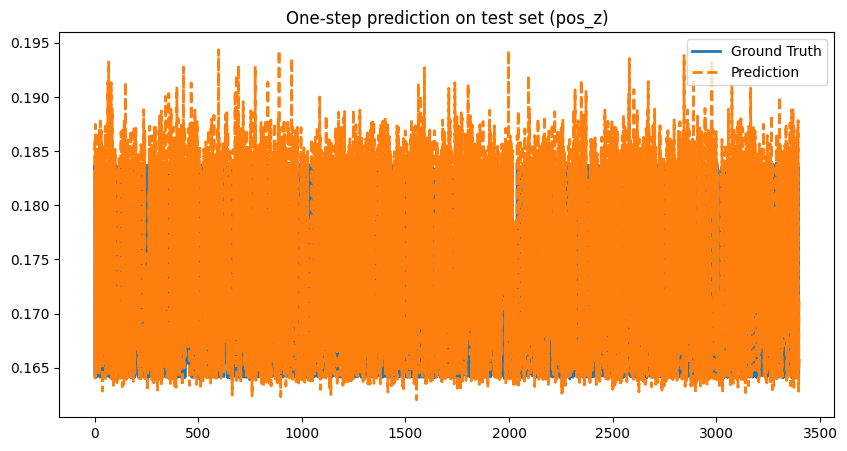

In [13]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    # preds = model(xb).cpu().numpy()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    Y_pred_full = model(X_test_tensor).cpu().numpy()

# Example: compare z position (index 2)
# plt.figure(figsize=(10,5))
# plt.plot(Y_test[:,2], label="Ground Truth")
# plt.plot(preds[:,2], label="Prediction")
# plt.legend()
# plt.title("One-step prediction (pos_z)")
# plt.show()

plt.figure(figsize=(10,5))
plt.plot(Y_test[:,2], label="Ground Truth", linewidth=2)
plt.plot(Y_pred_full[:,2], "--", label="Prediction", linewidth=2)
plt.legend()
plt.title("One-step prediction on test set (pos_z)")
plt.show()

## Rollout

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def rollout(model, X0, horizon, device="cpu"):
    """
    Rollout model predictions recursively for a given horizon.
    X0 : initial state+input (numpy array, shape [D])
    horizon : number of steps to simulate
    returns: array of predicted states [horizon, state_dim]
    """
    model.eval()
    preds = []
    x = torch.tensor(X0, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        for t in range(horizon):
            y = model(x)                      # predict next state
            assert y.shape[1] == model.net[-1].out_features, f"Got {y.shape}, expected {model.net[-1].out_features}"
            preds.append(y.cpu().numpy()[0])  # save as numpy
            # feed prediction back as new input (autoregressive)
            x = y.unsqueeze(0)

    return np.array(preds)


axis_names = {
    0: 'pos x',
    1: 'pos y',
    2: 'pos z',
    3: 'eul x',
    4: 'eul y',
    5: "eul z"
}

def evaluate_and_plot(model, X_test, Y_test, num_samples=200):
    """
    Compare model predictions vs ground truth over a test sequence.
    Args:
        model: trained HopperMLP
        X_test: np.array of shape (N, 14)
        Y_test: np.array of shape (N, 6)
        num_samples: number of timesteps to visualize
    """
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test[:num_samples], dtype=torch.float32)
        Y_true = Y_test[:num_samples]
        Y_pred = model(X_tensor).cpu().numpy()

    # Plot each state dimension
    fig, axs = plt.subplots(Y_true.shape[1], 1, figsize=(12, 2 * Y_true.shape[1]), sharex=True)
    timesteps = range(num_samples)

    for i in range(Y_true.shape[1]):
        axs[i].plot(timesteps, Y_true[:, i], label="Ground Truth", linewidth=2)
        axs[i].plot(timesteps, Y_pred[:, i], "--", label="Prediction", linewidth=2)
        axs[i].set_ylabel(axis_names[i]) #(f"State {i+1}")
        axs[i].legend(loc="upper right")

    axs[-1].set_xlabel("Timestep")
    plt.tight_layout()
    plt.show()


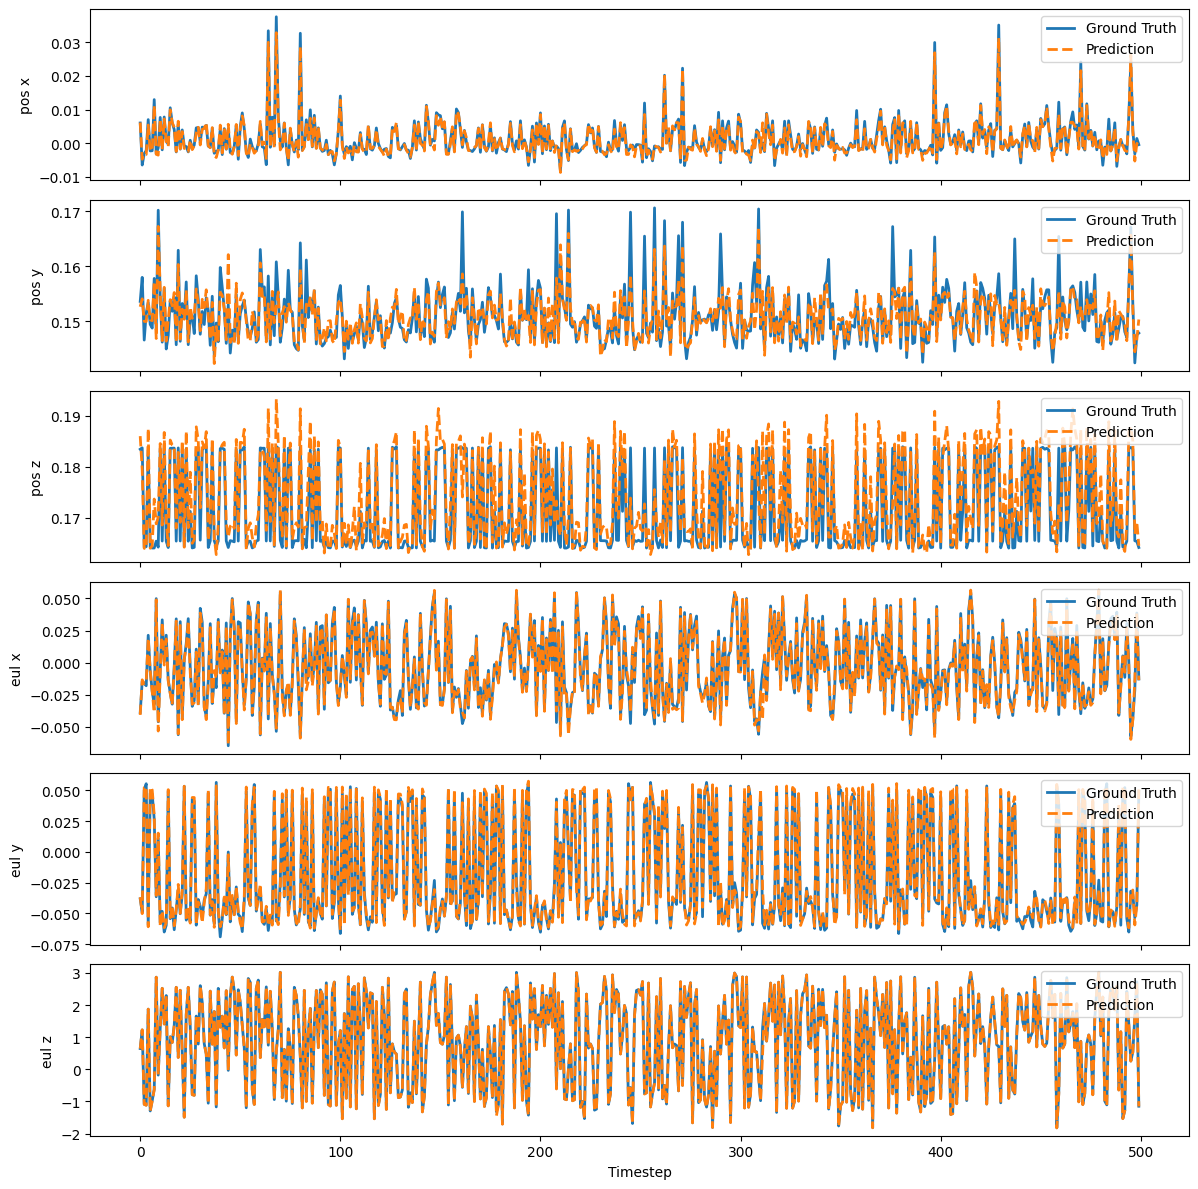

In [18]:
evaluate_and_plot(model, X_test, Y_test, num_samples=500)

## CEM MPC
Trained model as predictor inside controller with MuJoCo

### Helpers

In [24]:
import numpy as np
import torch

# --------------------------
# TODO Helpers I need to edit
# --------------------------
# FMAX_WING = 2.0e-5      # <-- per-wing max (N); set from your XML/mentor
FMAX_WING = 0.003
L = 0.015               # 15 mm (m), distance torso center to wing
DT = 1/80.0             # control step (match your downsampled data)
H = 20                  # horizon steps for MPC (e.g., 20 @ 80Hz ≈ 0.25s)
POP = 256               # CEM population
ELITES = 32             # CEM elites
ITERS = 4               # CEM iterations
CTRL_DIM = 4            # f1..f4
DEVICE = "cpu"

# Optional input/output normalization (set these if used in training)
X_mean, X_std = None, None
Y_mean, Y_std = None, None

def normalize_in(X):
    if X_mean is None: return X
    return (X - X_mean) / (X_std + 1e-8)

def denormalize_out(Y):
    if Y_mean is None: return Y
    return Y * (Y_std + 1e-8) + Y_mean

# Build 14-D input for MLP from state and action
def state_action_to_input(pos, eul, u_vec):
    # u = [f1..f4]
    f1,f2,f3,f4 = u_vec
    F  = f1 + f2 + f3 + f4
    Tx = -L*f1 + L*f2 + L*f3 - L*f4
    Ty = -L*f1 - L*f2 + L*f3 + L*f4
    # TODO: If training used a 3-D torque, set Tz=0 (or derive appropriately)
    Tz = 0.0
    # Signals: TODO: if 'rst_driving_signals' was the same as per-wing forces, use u directly.
    signals = np.array([f1,f2,f3,f4], dtype=np.float32)
    inp = np.hstack([pos, eul, [F], [Tx,Ty,Tz], signals]).astype(np.float32)
    return inp

# One learned dynamics step: x_{t+1} = f_hat(x_t, u_t)
def predict_next(model, pos, eul, u_vec):
    x_in = state_action_to_input(pos, eul, u_vec)
    x_in = normalize_in(x_in)
    x_t = torch.tensor(x_in, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        y = model(x_t).cpu().numpy()[0]   # 6-D next state
    y = denormalize_out(y)
    pos_next = y[:3]
    eul_next = y[3:6]
    return pos_next, eul_next

# Cost: track upright & desired COM height with small control penalty
# def mpc_cost(traj_pos, traj_eul, traj_u, z_des=0.20, w_up=3.0, w_z=1.0, w_u=1e-3):
#     """
#     traj_pos: [H,3], traj_eul: [H,3], traj_u: [H,4]
#     Cost encourages: near-zero roll/pitch, target height, small thrust.
#     """
#     roll, pitch = traj_eul[:,0], traj_eul[:,1]
#     z = traj_pos[:,2]
#     c_up = w_up * (roll**2 + pitch**2)
#     c_z  = w_z  * ((z - z_des)**2)
#     c_u  = w_u  * np.sum(traj_u**2, axis=1)
#     return np.sum(c_up + c_z + c_u)

def mpc_cost(traj_pos, traj_eul, traj_u,
             z_des=0.20, w_up=6.0, w_z=5.0, w_u=2e-4,
             w_omega=2.0, w_xy=2.0, traj_omega=None):
    roll, pitch, yaw = traj_eul.T  # [H]
    x, y, z = traj_pos.T
    c_up   = w_up * (roll**2 + pitch**2)            # attitude
    c_z    = w_z  * ((z - z_des)**2)                # height
    c_xy   = w_xy * (x**2 + y**2)                   # keep near vertical column
    c_u    = w_u  * np.sum(traj_u**2, axis=1)
    c_om   = 0.0
    if traj_omega is not None:
        c_om = w_omega * np.sum(traj_omega**2, axis=1)  # rate damping
    return np.sum(c_up + c_z + c_xy + c_u + c_om)


# CEM optimizer over an action *sequence* U = [u_0..u_{H-1}], u_t in [0,FMAX_WING]^4
def cem_optimize(model, pos0, eul0):
    mean = np.full((H, CTRL_DIM), FMAX_WING*0.25, dtype=np.float32)   # start modest
    std  = np.full((H, CTRL_DIM), FMAX_WING*0.25, dtype=np.float32)

    best_u_seq = None
    best_cost = np.inf

    for _ in range(ITERS):
        # sample
        U = np.random.normal(loc=mean, scale=std, size=(POP, H, CTRL_DIM)).astype(np.float32)
        U = np.clip(U, 0.0, FMAX_WING)

        # evaluate
        costs = np.zeros(POP, dtype=np.float64)
        for i in range(POP):
            pos = pos0.copy()
            eul = eul0.copy()
            traj_pos = []
            traj_eul = []
            for t in range(H):
                u_t = U[i, t]
                pos, eul = predict_next(model, pos, eul, u_t)
                traj_pos.append(pos)
                traj_eul.append(eul)
            traj_pos = np.asarray(traj_pos)
            traj_eul = np.asarray(traj_eul)
            costs[i] = mpc_cost(traj_pos, traj_eul, U[i])

        # elites
        elite_idx = np.argsort(costs)[:ELITES]
        elites = U[elite_idx]
        mean = elites.mean(axis=0)
        std  = elites.std(axis=0) + 1e-6

        if costs[elite_idx[0]] < best_cost:
            best_cost = costs[elite_idx[0]]
            best_u_seq = elites[0].copy()

    return best_u_seq[0]  # return only first control (receding horizon)


def mj_get_state(env):
    """
    dm_control style. If you use mujoco-py or mujoco-python, adapt to that API.
    Must return pos(3) and eulXYZ(3) consistent with your training.
    """
    # Example using named accessors (TODO: adjust to model!)
    p = env.physics.named.data.xpos['torso']       # world COM or body position
    # TODO: If trained on a specific position signal, read that instead.
    pos = np.array([p[0], p[1], p[2]], dtype=np.float32)

    # Euler XYZ from rotation matrix or quat
    R = env.physics.named.data.xmat['torso'].reshape(3,3)
    # naive XYZ extraction (TODO: ensure consistency with rst_Eul_XYZ!)
    pitch = np.arcsin(-R[2,0])
    roll  = np.arctan2(R[2,1], R[2,2])
    yaw   = np.arctan2(R[1,0], R[0,0])
    eul = np.array([roll, pitch, yaw], dtype=np.float32)
    return pos, eul

# def mj_apply_u(env, u_vec):
#     """
#     Write the chosen per-wing thrusts into MuJoCo controls.
#     Names must match your XML (f1..f4 actuators).
#     """
#     env.physics.named.data.ctrl['f1'] = u_vec[0]
#     env.physics.named.data.ctrl['f2'] = u_vec[1]
#     env.physics.named.data.ctrl['f3'] = u_vec[2]
#     env.physics.named.data.ctrl['f4'] = u_vec[3]

def mj_apply_u(model, data, u_vec):
    data.ctrl[actuator_name_to_id(model,'leg-motor')] = u_vec[0]
    data.ctrl[actuator_name_to_id(model,'f1')] = u_vec[1]
    data.ctrl[actuator_name_to_id(model,'f2')] = u_vec[2]
    data.ctrl[actuator_name_to_id(model,'f3')] = u_vec[3]
    data.ctrl[actuator_name_to_id(model,'f4')] = u_vec[4]


def mpc_control_step(env, model):
    pos, eul = mj_get_state(env)
    u0 = cem_optimize(model, pos, eul)
    mj_apply_u(env, u0)
    # advance MuJoCo by one control interval (match DT)
    # If your env uses smaller physics dt, step multiple times to match DT.
    substeps = max(1, int(DT / env.physics.model.opt.timestep + 1e-9))
    for _ in range(substeps):
        env.step()
    return u0


### MuJoCo Simulation and Render

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


HOPPER_XML = "flying_hopper.xml"
MODEL_WEIGHTS = "hopper_mlp.pt"   # set to your saved weights (if any)
OUT_VIDEO = "hopper_mpc.mp4"

# LEG_MAX = 1.0      # N 
# WING_MAX = 1.0 # 2.0e-5  # N
FMAX_WING = 2e-5

L = 0.015
DT_CTRL = 1/80.0   # control interval (s)
H = 20
POP = 256
ELITES = 32
ITERS = 4
CTRL_DIM = 4
DEVICE = "cpu"

# Optional normalization placeholders (set if you used them in training)
X_mean, X_std = None, None
Y_mean, Y_std = None, None

def normalize_in(X):
    if X_mean is None: return X
    return (X - X_mean) / (X_std + 1e-8)

def denormalize_out(Y):
    if Y_mean is None: return Y
    return Y * (Y_std + 1e-8) + Y_mean

# -------------------------
# state/action -> model input (same as you posted)
# -------------------------
def state_action_to_input(pos, eul, u_vec):
    f1,f2,f3,f4 = u_vec
    F  = f1 + f2 + f3 + f4
    Tx = -L*f1 + L*f2 + L*f3 - L*f4
    Ty = -L*f1 - L*f2 + L*f3 + L*f4
    Tz = 0.0
    signals = np.array([f1,f2,f3,f4], dtype=np.float32)
    inp = np.hstack([pos, eul, [F], [Tx,Ty,Tz], signals]).astype(np.float32)
    return inp


def predict_next_np(model_torch, pos, eul, u_vec):
    x_in = state_action_to_input(pos, eul, u_vec)
    x_in = normalize_in(x_in)
    x_t = torch.tensor(x_in, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        y = model_torch(x_t).cpu().numpy()[0]
    y = denormalize_out(y)
    pos_next = y[:3].astype(np.float32)
    eul_next = y[3:6].astype(np.float32)
    return pos_next, eul_next

def mpc_cost(traj_pos, traj_eul, traj_u, z_des=0.20, w_up=3.0, w_z=1.0, w_u=1e-3):
    roll, pitch = traj_eul[:,0], traj_eul[:,1]
    z = traj_pos[:,2]
    c_up = w_up * (roll**2 + pitch**2)
    c_z  = w_z  * ((z - z_des)**2)
    c_u  = w_u  * np.sum(traj_u**2, axis=1)
    return np.sum(c_up + c_z + c_u)


def cem_optimize(model_torch, pos0, eul0):
    mean = np.full((H, CTRL_DIM), FMAX_WING*0.25, dtype=np.float32)
    std  = np.full((H, CTRL_DIM), FMAX_WING*0.25, dtype=np.float32)
    best_u_seq = None
    best_cost = np.inf

    for _ in range(ITERS):
        U = np.random.normal(loc=mean, scale=std, size=(POP, H, CTRL_DIM)).astype(np.float32)
        U = np.clip(U, 0.0, FMAX_WING)
        costs = np.zeros(POP, dtype=np.float64)
        for i in range(POP):
            pos = pos0.copy()
            eul = eul0.copy()
            traj_pos = []
            traj_eul = []
            for t in range(H):
                u_t = U[i, t]
                pos, eul = predict_next_np(model_torch, pos, eul, u_t)
                traj_pos.append(pos)
                traj_eul.append(eul)
            traj_pos = np.asarray(traj_pos)
            traj_eul = np.asarray(traj_eul)
            costs[i] = mpc_cost(traj_pos, traj_eul, U[i])
        elite_idx = np.argsort(costs)[:ELITES]
        elites = U[elite_idx]
        mean = elites.mean(axis=0)
        std  = elites.std(axis=0) + 1e-6
        if costs[elite_idx[0]] < best_cost:
            best_cost = costs[elite_idx[0]]
            best_u_seq = elites[0].copy()

    return best_u_seq[0]

# -------------------------
# MuJoCo helpers (model,data style)
# -------------------------
def body_name_to_id(mjmodel, name):
    # returns body id; if this raises, replace with your API variant
    return mujoco.mj_name2id(mjmodel, mujoco.mjtObj.mjOBJ_BODY, name)

def actuator_name_to_id(mjmodel, name):
    return mujoco.mj_name2id(mjmodel, mujoco.mjtObj.mjOBJ_ACTUATOR, name)

def get_torso_pos_eul(mjmodel, mjdata, body_name='hopper'):
    # body index
    bid = body_name_to_id(mjmodel, body_name)
    # data.xpos is (nbody,3)
    pos = np.array(mjdata.xpos[bid], dtype=np.float32)

    # data.xmat stores rotation matrices in rows of length 9; convert to (nbody,3,3)
    # In mujoco bindings data.xmat can be reshaped safely:
    R_all = np.asarray(mjdata.xmat).reshape(-1, 3, 3)
    R = R_all[bid]
    # extract XYZ (roll,pitch,yaw) in the same convention you trained with:
    pitch = np.arcsin(np.clip(-R[2,0], -1.0, 1.0))
    roll  = np.arctan2(R[2,1], R[2,2])
    yaw   = np.arctan2(R[1,0], R[0,0])
    eul = np.array([roll, pitch, yaw], dtype=np.float32)
    return pos, eul

def apply_ctrl_to_data(mjmodel, mjdata, u_vec):
    # actuator ids for f1..f4
    # assumes your actuators are named 'f1','f2','f3','f4'
    idxs = [actuator_name_to_id(mjmodel, name) for name in ('f1','f2','f3','f4')]
    for i, aidx in enumerate(idxs):
        mjdata.ctrl[aidx] = float(u_vec[i])

# -------------------------
# Closed-loop run and rendering
# -------------------------
def run_closed_loop_and_record(hopper_xml=HOPPER_XML, model_weights=None,
                               sim_time=5.0, fps=80, camera_name=None):
    # 1) load mujoco model & data
    mjmodel = mujoco.MjModel.from_xml_path(hopper_xml)
    mjdata  = mujoco.MjData(mjmodel)

    # 2) renderer
    width, height = 640, 480
    renderer = mujoco.Renderer(mjmodel, width=width, height=height)

    # 3) load pytorch model architecture + weights
    # NOTE: set the correct input/output dims used in your training
    input_dim = 14   # your X.shape[1]
    output_dim = 6   # your Y.shape[1]
    net = HopperMLP(input_dim=input_dim, output_dim=output_dim, hidden_dim=32).to(DEVICE)
    if model_weights is not None and os.path.exists(model_weights):
        net.load_state_dict(torch.load(model_weights, map_location=DEVICE))
    net.eval()

    # 4) time & frame bookkeeping
    fps = int(fps)
    n_frames = int(sim_time * fps)
    dt_video = 1.0 / fps
    # physics steps per video frame:
    steps_per_frame = max(1, int(round(dt_video / mjmodel.opt.timestep)))

    frames = []
    simt = 0.0

    # optional: set initial state qpos/qvel in mjdata if desired
    # e.g., mjdata.qpos[:] = <initial qpos vector>

    torso_t, torso_x, torso_y, torso_z = [], [], [], []
    sys_t,   sys_x,   sys_y,   sys_z   = [], [], [], []


    for frame_idx in range(n_frames):
        # Control is run at the same rate as video frames in this script.
        # If you want slower control than video fps, update only every N frames.
        pos, eul = get_torso_pos_eul(mjmodel, mjdata, body_name='hopper')

        # CEM to compute u0
        t0 = time.time()
        u0 = cem_optimize(net, pos, eul)
        print("u0:", u0)
        print("CEM took", time.time()-t0, "seconds")

        # Apply control and step physics steps_per_frame times
        apply_ctrl_to_data(mjmodel, mjdata, u0)
        for _ in range(steps_per_frame):
            mujoco.mj_step(mjmodel, mjdata)


        # --- Log torso COM ---
        bid = body_name_to_id(mjmodel, "hopper")   # torso body
        torso_pos = np.array(mjdata.xpos[bid])     # (x,y,z) of torso
        torso_t.append(simt)
        torso_x.append(torso_pos[0])
        torso_y.append(torso_pos[1])
        torso_z.append(torso_pos[2])

        # Log system COM (all bodies) ---
        sys_pos = np.array(mjdata.subtree_com[0])  # model-wide COM
        sys_t.append(simt)
        sys_x.append(sys_pos[0])
        sys_y.append(sys_pos[1])
        sys_z.append(sys_pos[2])


        # Debugging
        print("ctrl:", mjdata.ctrl)                # what was commanded
        print("act_force:", mjdata.actuator_force) # actuator forces applied



        # Update renderer with the new state and render frame
        renderer.update_scene(mjdata)
        # optionally pass camera_name to renderer.render(camera_name=...)
        frame = renderer.render()  # returns RGB uint8
        frames.append(frame)

        simt += steps_per_frame * mjmodel.opt.timestep

        # optional: print progress
        if (frame_idx % 50) == 0:
            print(f"frame {frame_idx}/{n_frames} sim_time={simt:.4f} s")

    # write out video
    imageio.mimsave(OUT_VIDEO, frames, fps=fps)
    print("Saved video:", OUT_VIDEO)

        # --- 2D plots: torso vs system COM ---
    plt.figure(figsize=(10,6))
    plt.plot(torso_t, torso_x, label="Torso X")
    plt.plot(torso_t, torso_y, label="Torso Y")
    plt.plot(torso_t, torso_z, label="Torso Z")
    plt.plot(sys_t, sys_x, "--", label="System X")
    plt.plot(sys_t, sys_y, "--", label="System Y")
    plt.plot(sys_t, sys_z, "--", label="System Z")
    plt.xlabel("Time [s]")
    plt.ylabel("Position [m]")
    plt.title("Torso vs System COM Trajectory (x,y,z vs time)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- 3D plot: torso COM ---
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(torso_x, torso_y, torso_z, label="Torso COM", linewidth=2)
    ax.plot(sys_x, sys_y, sys_z, "--", label="System COM", linewidth=2)
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.set_title("3D Hopper COM trajectory (Torso vs System)")
    ax.legend()
    plt.show()



if __name__ == "__main__":
    run_closed_loop_and_record(hopper_xml=HOPPER_XML, model_weights=MODEL_WEIGHTS,
                               sim_time=6.0, fps=80, camera_name=None)



NameError: name 'time' is not defined

## Frame Realign

### old code

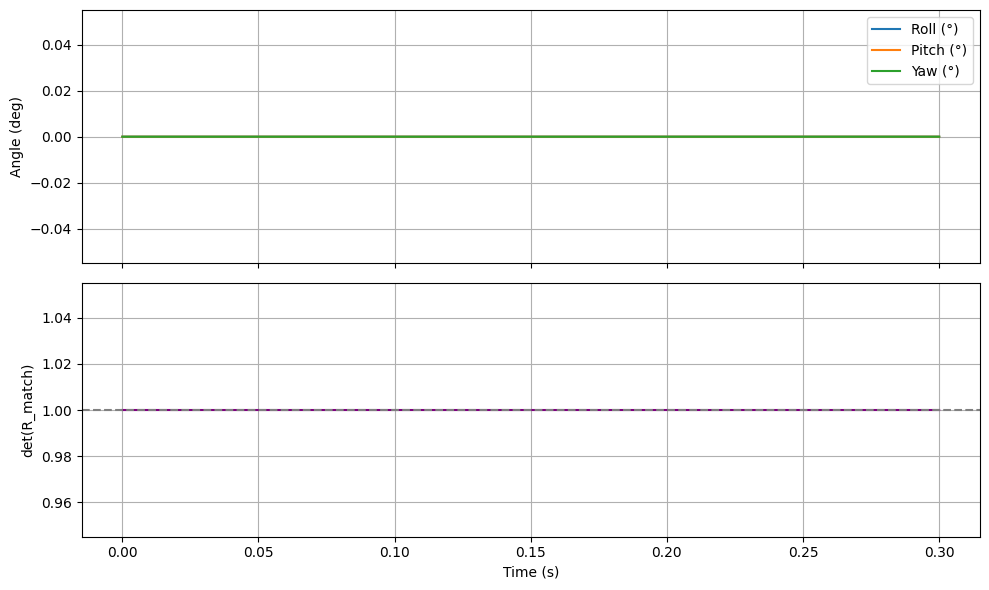

In [ ]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# --- imports from your control_utils.py ---
from legacy.control_utils import build_R_match, body_to_nn, get_body_rotation_matrix, get_body_omega

xml_path = "hopper.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

# Sim duration and step setup
sim_time = 0.3  # seconds
dt = model.opt.timestep
steps = int(sim_time / dt)

# Storage
det_R_match = []
roll, pitch, yaw = [], [], []

# Reference forward direction (world frame)
R_mpc_1 = np.array([1.0, 0.0, 0.0])

for _ in range(steps):
    mujoco.mj_step(model, data)

    R_body = get_body_rotation_matrix(model, data, body_name="main")
    omega_body = get_body_omega(data)

    R_match = build_R_match(R_body, R_mpc_1)
    q_nn, omega_nn = body_to_nn(R_body, omega_body, R_match)

    det_R_match.append(np.linalg.det(R_match))

    # body Euler angles
    eul = R.from_matrix(R_body).as_euler('xyz', degrees=True)
    roll.append(eul[0]); pitch.append(eul[1]); yaw.append(eul[2])

# --- Plot results ---
t = np.linspace(0, sim_time, steps)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t, roll, label="Roll (°)")
axs[0].plot(t, pitch, label="Pitch (°)")
axs[0].plot(t, yaw, label="Yaw (°)")
axs[0].set_ylabel("Angle (deg)")
axs[0].legend(); axs[0].grid()

axs[1].plot(t, det_R_match, color="purple")
axs[1].axhline(1.0, ls="--", color="gray")
axs[1].set_ylabel("det(R_match)")
axs[1].set_xlabel("Time (s)")
axs[1].grid()

plt.tight_layout()
plt.show()


### Evaluation Utilities

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_test, Y_test):
    model.eval()
    with torch.no_grad():
        Y_pred = model(torch.tensor(X_test, dtype=torch.float32)).cpu().numpy()
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred, multioutput='raw_values'))
    mae  = mean_absolute_error(Y_test, Y_pred, multioutput='raw_values')
    print("=== Model Evaluation ===")
    for i,(r,m) in enumerate(zip(rmse, mae), 1):
        print(f"State {i}: RMSE={r:.4e}, MAE={m:.4e}")
    print("========================")
    return Y_pred, rmse, mae

def evaluate_and_plot(model, X_test, Y_test, num_samples=500):
    model.eval()
    with torch.no_grad():
        Yp = model(torch.tensor(X_test[:num_samples], dtype=torch.float32)).cpu().numpy()
    Yt = Y_test[:num_samples]
    fig, axs = plt.subplots(Yt.shape[1], 1, figsize=(12, 2.2*Yt.shape[1]), sharex=True)
    t = np.arange(num_samples)
    for i in range(Yt.shape[1]):
        axs[i].plot(t, Yt[:,i], label='GT')
        axs[i].plot(t, Yp[:,i], '--', label='Pred')
        axs[i].set_ylabel(f"State {i+1}")
        axs[i].legend(loc='upper right')
    axs[-1].set_xlabel('Timestep')
    plt.tight_layout(); plt.show()
    return Yp


### Frame Realignment
The above pipeline causes the hopper to do an odd flip before falling over. This may be in part due to the lack of yaw control interefering by presenting the model with unseen states. We implement frame realignment below so that the yaw on the system has no effect.

In [ ]:
import importlib, legacy.control_utils as control_utils
importlib.reload(control_utils)

from legacy.control_utils import (
    build_R_match, body_to_nn, tau_nn_to_body,
    allocate_per_wing_forces, f_to_voltage,
    get_body_rotation_matrix, get_body_omega, set_wing_forces_by_name
)

def mpc_control_step(model, data, net, R_mpc_1=np.array([1,0,0])):
    """
    Returns:
      f_vec   : per-wing forces (N), shape (4,)
      tau_body: np.array(3,), here zeros unless you add a torque head
      R_match : 3x3
    """
    # 1) read state
    R_body = get_body_rotation_matrix(model, data, body_name="main")
    omega_body = get_body_omega(data)

    # 2) frame realignment (kept for later torque use / NN frame)
    R_match = build_R_match(R_body, R_mpc_1)
    q_nn, omega_nn = body_to_nn(R_body, omega_body, R_match)

    # 3) CEM: plan the *per-wing* forces directly (simplest, no allocator)
    pos = data.qpos[0:3].copy()
    eul = np.array(R.from_matrix(R_body).as_euler('xyz'))
    u0 = cem_optimize(net, pos, eul)             # expect shape (4,), per-wing
    f_vec_raw = np.asarray(u0, dtype=np.float64)

    # 4) (optional) add hover bias around which CEM modulates
    MASS = 0.00095 + 0.00020  # tweak to your actual masses
    F_hover = MASS * 9.81
    f_hover = (F_hover / 4.0)
    # f_vec = np.clip(f_vec_raw + f_hover, 0.0, np.inf)
    SCALE = 0.4        # try 0.4 first; adjust between 0.2–0.6 as needed
    f_hover = 0.0023   # per-wing hover thrust in N (≈ total 0.009 N)
    f_vec = np.clip(f_vec_raw * SCALE + f_hover, 0.0, 0.005)
    print(f"[DEBUG] Thrusts: {np.round(f_vec,6)}, total={np.sum(f_vec):.5f} N")

    # 5) no leg motor write unless your XML has one!
    # set wing forces (no xml stepping inside)
    set_wing_forces_by_name(model, data, f_vec)

    tau_body = np.zeros(3)  # placeholder (no torque head)
    return f_vec, tau_body, R_match





def euler_to_matrix(eul):
    roll, pitch, yaw = eul
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(roll), -np.sin(roll)],
                   [0, np.sin(roll),  np.cos(roll)]])
    Ry = np.array([[ np.cos(pitch), 0, np.sin(pitch)],
                   [0, 1, 0],
                   [-np.sin(pitch), 0, np.cos(pitch)]])
    Rz = np.array([[ np.cos(yaw), -np.sin(yaw), 0],
                   [ np.sin(yaw),  np.cos(yaw), 0],
                   [ 0, 0, 1]])
    return Rz @ Ry @ Rx

# TODO: plot Euler angle after realignment, Z should be close to 0


In [ ]:
mj_model = mujoco.MjModel.from_xml_path("flying_hopper.xml")
mj_data = mujoco.MjData(mj_model)

R_body = get_body_rotation_matrix(mj_model, mj_data, body_name="main")
print("R_body:\n", R_body)
print("det(R_body):", np.linalg.det(R_body))


[WARN] Invalid R_body for main: replacing with identity.
R_body:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
det(R_body): 1.0


[DEBUG] Thrusts: [0.0023   0.0023   0.002306 0.002301], total=0.00921 N
Frame 0/480  t=0.012s  f=[0.0023   0.0023   0.002306 0.002301]
[DEBUG] Thrusts: [0.0023   0.002303 0.002302 0.002302], total=0.00921 N
[DEBUG] Thrusts: [0.002303 0.002301 0.002304 0.002301], total=0.00921 N
[DEBUG] Thrusts: [0.002304 0.002304 0.002301 0.002303], total=0.00921 N
[DEBUG] Thrusts: [0.002302 0.0023   0.002302 0.002302], total=0.00921 N
[DEBUG] Thrusts: [0.0023   0.002301 0.0023   0.002304], total=0.00921 N
[DEBUG] Thrusts: [0.0023   0.002301 0.002302 0.0023  ], total=0.00920 N
[DEBUG] Thrusts: [0.002301 0.002302 0.002303 0.0023  ], total=0.00921 N
[DEBUG] Thrusts: [0.002301 0.0023   0.0023   0.002303], total=0.00920 N
[DEBUG] Thrusts: [0.002302 0.0023   0.002302 0.0023  ], total=0.00920 N
[DEBUG] Thrusts: [0.002301 0.0023   0.002303 0.002304], total=0.00921 N
[DEBUG] Thrusts: [0.0023   0.002302 0.002302 0.0023  ], total=0.00920 N
[DEBUG] Thrusts: [0.002303 0.0023   0.002304 0.002302], total=0.00921 N
[

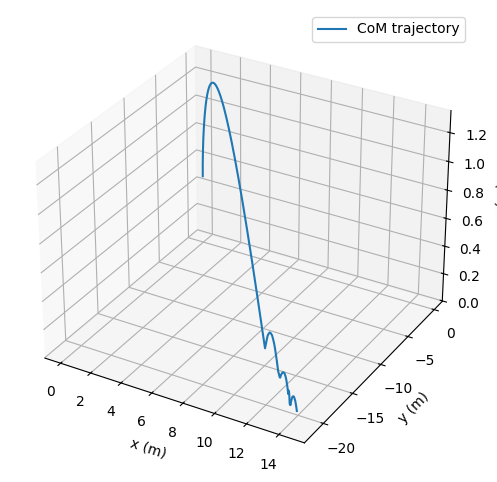

In [ ]:
"""
Frame-Realigned MPC Control for Hopper
--------------------------------------
This version augments the original MPC/CEM pipeline with:
  - frame realignment (R_match)
  - per-wing thrust allocation
  - optional torque transformations
"""

import os, time, numpy as np, torch, mujoco, imageio
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt

# ---------------------------------------------------
# IMPORTS FROM YOUR EXISTING CODEBASE
# ---------------------------------------------------
# from hopper_mlp import HopperMLP      # (same model class)
from legacy.control_utils import (
    build_R_match, body_to_nn, tau_nn_to_body,
    allocate_per_wing_forces, f_to_voltage,
    get_body_rotation_matrix, get_body_omega, set_wing_forces_by_name
)
# from cem_optimizer import cem_optimize   # your existing CEM optimizer


# ---------------------------------------------------
# CONSTANTS
# ---------------------------------------------------
HOPPER_XML = "flying_hopper.xml"
MODEL_WEIGHTS = "hopper_mlp.pt"
OUT_VIDEO = "hopper_mpc_realign.mp4"

DT_CTRL = 1/80.0
DEVICE = "cpu"
R_MPC_1 = np.array([1, 0, 0])   # desired x-axis for realignment


# ---------------------------------------------------
# SIMULATION + RENDERING
# ---------------------------------------------------
def run_closed_loop_and_record(hopper_xml="flying_hopper.xml", model_weights=None,
                               sim_time=6.0, fps=80):
    model = mujoco.MjModel.from_xml_path(hopper_xml)
    data  = mujoco.MjData(model)
    mujoco.mj_forward(model, data)

    # renderer
    renderer = mujoco.Renderer(model, width=640, height=480)

    # load net
    net = HopperMLP(input_dim=14, output_dim=6, hidden_dim=32).to(DEVICE)
    if model_weights and os.path.exists(model_weights):
        net.load_state_dict(torch.load(model_weights, map_location=DEVICE))
    net.eval()

    # timing
    n_frames = int(sim_time * fps)
    dt_video = 1.0 / fps
    dt_phys  = model.opt.timestep
    steps_per_frame = max(1, int(round(dt_video / dt_phys)))
    ctrl_every = max(1, int(round(DT_CTRL / dt_phys)))

    frames, com_log = [], []
    simt = 0.0
    last_f = np.zeros(4)

    for frame_idx in range(n_frames):
        for s in range(steps_per_frame):
            if (s % ctrl_every) == 0:
                # ONE control update, no stepping inside
                last_f, tau_body, R_match = mpc_control_step(model, data, net, R_MPC_1)

            mujoco.mj_step(model, data)
            simt += dt_phys

        com_log.append(data.subtree_com[0].copy())
        renderer.update_scene(data)
        frames.append(renderer.render())

        if frame_idx % 50 == 0:
            print(f"Frame {frame_idx}/{n_frames}  t={simt:.3f}s  f={np.round(last_f,6)}")

    imageio.mimsave(OUT_VIDEO, frames, fps=fps)
    print("Saved video:", OUT_VIDEO)
    return np.array(com_log)





# ---------------------------------------------------
# MAIN
# ---------------------------------------------------
if __name__ == "__main__":
    com_log = run_closed_loop_and_record(sim_time=6.0)

    # Plot COM trajectory
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(com_log[:,0], com_log[:,1], com_log[:,2], label="CoM trajectory")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
    ax.legend(); plt.show()


# OLD CODE

In [ ]:

# ---------------------------------------------------
# CORE CONTROL FUNCTION
# ---------------------------------------------------

# def mpc_control_step(model, data, net, R_mpc_1=np.array([1, 0, 0])):
#     """
#     One full MPC + frame realignment control step.
#     Inputs:
#         model, data : mujoco.MjModel and MjData
#         net         : trained dynamics model or policy used in CEM optimization
#         R_mpc_1     : desired x-axis direction for frame realignment (usually [1,0,0])
#     Returns:
#         f_vec       : per-wing thrusts (4,)
#         tau_body    : body torque command (3,)
#         R_match     : alignment matrix
#     """

#     # ---------------------------
#     # 1. Read current state
#     # ---------------------------
#     R_body = get_body_rotation_matrix(model, data, body_name="main")  # 3×3 rotation
#     omega_body = get_body_omega(data)                            # angular velocity (3,)

#     # ---------------------------
#     # 2. Frame realignment
#     # ---------------------------
#     R_match = build_R_match(R_body, R_mpc_1)
#     q_nn, omega_nn = body_to_nn(R_body, omega_body, R_match) # need to use this
#     # TODO need to mult by R_match
#     # NN should take pos vel eul/quat and ang velocity and should be training with this too

#     # ---------------------------
#     # 3. Query controller (CEM / MPC)
#     # ---------------------------
#     # Here your optimizer should use the *realigned* state
#     pos = data.qpos[0:3].copy()      # hopper position
#     eul = np.array(R.from_matrix(R_body).as_euler('xyz'))  # Euler angles from R_body

#     u0 = cem_optimize(net, pos, eul)   # -> control vector [leg, f1, f2, f3, f4] in NN frame
#     F_cmd_nn = np.sum(u0[1:])          # total thrust command
#     tau_nn = np.zeros(3)               # placeholder if you later add NN torque outputs

#     # ---------------------------
#     # 4. Transform torque to body frame
#     # ---------------------------
#     tau_body = tau_nn_to_body(tau_nn, R_match)
#     Tx_cmd, Ty_cmd = float(tau_body[0]), float(tau_body[1])
#     Tx_ext, Ty_ext = 0.0, 0.0  # no external torque compensation yet

#     # ---------------------------
#     # 5. Allocate per-wing thrusts
#     # ---------------------------
#     f_vec = allocate_per_wing_forces(F_cmd_nn, Tx_cmd, Ty_cmd, Tx_ext, Ty_ext)

#     # ---------------------------
#     # 6. Apply to MuJoCo actuators
#     # ---------------------------
#     set_wing_forces_by_name(data, f_vec)
#     data.ctrl[0] = u0[0]  # leg actuator if present

#     # ---------------------------
#     # 7. Step physics
#     # ---------------------------
#     mujoco.mj_step(model, data)

#     return f_vec, tau_body, R_match

# def mpc_control_step(model, data, net, R_mpc_1=R_MPC_1):
#     """One control step with frame realignment and per-wing allocation."""

#     # 1. State extraction
#     R_body = get_body_rotation_matrix(data, body_name="hopper")
#     omega_body = get_body_omega(data)

#     # 2. Frame realignment
#     R_match = build_R_match(R_body, R_mpc_1)
#     q_nn, omega_nn = body_to_nn(R_body, omega_body, R_match)

#     # 3. CEM-based MPC in NN frame
#     pos = data.qpos[0:3].copy()
#     eul = np.array(R.from_matrix(R_body).as_euler('xyz'))
#     u0 = cem_optimize(net, pos, eul)     # [leg, f1, f2, f3, f4]
#     F_cmd_nn = np.sum(u0[1:])            # total thrust (NN frame)

#     # 4. Transform torque NN→body (if any torque output added later)
#     tau_nn = np.zeros(3)
#     tau_body = tau_nn_to_body(tau_nn, R_match)
#     Tx_cmd, Ty_cmd = tau_body[0], tau_body[1]

#     # 5. Allocate per-wing forces
#     f_vec = allocate_per_wing_forces(F_cmd_nn, Tx_cmd, Ty_cmd)

#     # 6. Apply to actuators
#     set_wing_forces_by_name(data, f_vec)
#     data.ctrl[0] = u0[0]   # leg actuator (if present)

#     mujoco.mj_step(model, data)
#     return f_vec, tau_body, R_match



# def run_closed_loop_and_record(hopper_xml=HOPPER_XML, model_weights=None,
#                                sim_time=5.0, fps=80):
#     model = mujoco.MjModel.from_xml_path(hopper_xml)
#     data = mujoco.MjData(model)

#     width, height = 640, 480
#     renderer = mujoco.Renderer(model, width=width, height=height)

#     # Load model
#     net = HopperMLP(input_dim=14, output_dim=6, hidden_dim=32).to(DEVICE)
#     if model_weights and os.path.exists(model_weights):
#         net.load_state_dict(torch.load(model_weights, map_location=DEVICE))
#     net.eval()

#     n_frames = int(sim_time * fps)
#     # frames, com_log = [], []

#     # after loading model/data:
#     mujoco.mj_forward(mj_model, mj_data)  # init derived quantities

#     fps = 80
#     dt_video = 1.0 / fps
#     dt_phys  = mj_model.opt.timestep              # 1e-4 from XML
#     steps_per_frame = max(1, int(round(dt_video / dt_phys)))

#     DT_CTRL = 1/80.0                               # your control rate
#     ctrl_every = max(1, int(round(DT_CTRL / dt_phys)))

#     frames, com_log = [], []
#     simt = 0.0

#     for frame_idx in range(n_frames):
#         # substep physics many times per video frame
#         for s in range(steps_per_frame):
#             # run control at DT_CTRL
#             if (s % ctrl_every) == 0:
#                 # ONE control update that may depend on mj_model, mj_data, net, R_MPC_1
#                 f_vec, tau_body, R_match = mpc_control_step(mj_model, mj_data, net, R_MPC_1)
#                 # (inside mpc_control_step DO NOT call mj_step — the outer loop does that)

#             mujoco.mj_step(mj_model, mj_data)      # advance physics by dt_phys
#             simt += dt_phys

#         # record & render once per video frame
#         com_log.append(mj_data.subtree_com[0].copy())
#         renderer.update_scene(mj_data)
#         frame = renderer.render()
#         frames.append(frame)

#         if frame_idx % 50 == 0:
#             print(f"Frame {frame_idx}/{n_frames}  sim_t={simt:.3f}s  thrust={np.round(f_vec, 6)}")


#     imageio.mimsave(OUT_VIDEO, frames, fps=fps)
#     print(f"Saved video: {OUT_VIDEO}")
#     return np.array(com_log)

# assume you have model, data (mujoco.MjModel, MjData), and a trained NN controller `nn_control`
# nn_control should accept q_nn, omega_nn and output [F_cmd_nn, tau_nn_x, tau_nn_y] in NN frame.

# helper to get body rotation matrix and angular velocity from MuJoCo data
def get_body_rotation_matrix(data, body_name="torso"):
    # adjust call depending on your API / wrapper
    # for mujoco-python, you can use named accessors:
    idx = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, body_name)
    R_body_flat = data.xmat[idx*9:(idx+1)*9] if False else data.xmat[idx].copy()  # adjust if needed
    # safer to use data.xpos and data.xmat with correct shapes in your API
    # here I'll assume data.xmat[name].reshape(3,3) is available
    # replace the above with your environment's accessor
    return data.xmat[idx].reshape(3,3)   # may need adaptation

def get_body_omega(data):
    # example: qvel indexes depend on whether you used freejoint; adapt accordingly
    # If freejoint: qvel[3:6] are angular rates in body frame (or world - check)
    return data.qvel[3:6].copy()

# get actuator ctrl index names - you can assign by name if your wrapper supports it
def set_wing_forces_by_name(data, f_vec):
    # if your environment supports named.ctrl like dm_control or gym wrapper:
    try:
        data.ctrl[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, 'f1')] = f_vec[0]
        data.ctrl[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, 'f2')] = f_vec[1]
        data.ctrl[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, 'f3')] = f_vec[2]
        data.ctrl[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, 'f4')] = f_vec[3]
    except Exception:
        # fallback: if you know ctrl ordering, write indices directly, e.g. ctrl[1:5]
        data.ctrl[1:5] = f_vec  # adjust indices to match your actuator order

# ---------- control step (one physics-control cycle) ----------
def control_step(model, data, R_mpc_1):
    # 1) read current orientation & angular vel from sim
    # (adjust retrieving code to your API)
    # Example using dm_control-like API (adapt as needed)
    R_body = get_body_rotation_matrix(data, body_name="torso")  # 3x3
    omega_body = get_body_omega(data)                            # (3,)

    # 2) Build alignment matrix and transform state into NN frame
    R_match = build_R_match(R_body, R_mpc_1)
    q_nn, omega_nn = body_to_nn(R_body, omega_body, R_match)

    # 3) Query NN controller (returns torque in NN frame and desired total thrust)
    # Example signature: F_cmd_nn (scalar), tau_nn (3-vector)
    F_cmd_nn, tau_nn = nn_control(q_nn, omega_nn)  # implement your NN call
    # If nn_control returns e.g. [F_cmd, Tx_nn, Ty_nn], adapt accordingly

    # 4) Transform torque back to body frame
    tau_body = tau_nn_to_body(np.array(tau_nn), R_match)
    Tx_cmd = float(tau_body[0])
    Ty_cmd = float(tau_body[1])
    # (ignore τz since yaw not actuated)

    # 5) optionally estimate external torques (here zero or from sensors/observer)
    Tx_ext = 0.0
    Ty_ext = 0.0

    # 6) allocate per-wing forces
    # f_vec = allocate_per_wing_forces(float(F_cmd_nn), Tx_cmd, Ty_cmd, Tx_ext, Ty_ext)
    # ---- quick debug scaling ----
    SCALE = 0.4        # try 0.4 first; adjust between 0.2–0.6 as needed
    f_hover = 0.0023   # per-wing hover thrust in N (≈ total 0.009 N)
    f_vec = np.clip(f_vec_raw * SCALE + f_hover, 0.0, 0.005)
    print(f"[DEBUG] Thrusts: {np.round(f_vec,6)}, total={np.sum(f_vec):.5f} N")


    # 7) send to actuators (or convert to voltages)
    set_wing_forces_by_name(data, f_vec)

    # 8) if you need voltages for hardware mapping:
    voltages = f_to_voltage(f_vec)

    return f_vec, voltages


# Adding Disturbances
1. Start from pertubed initial state
2. Apply external force/impulse